# Sensitivity Analysis — PEM and AEC Electrolyzer Capacity

Given a fixed DRI trajectory (70% by 2050), which electrolyzer technology parameters drive PEM and AEC capacity?

- **PEM capacity** → directly determines iridium demand
- **AEC capacity** → directly determines nickel demand

DRI share is a scenario assumption and appears in the scenario comparison, not here.

## Imports + baseline

In [120]:
import sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.append('..')
from model_functions import run_scenario

# ── Baseline: 70% DRI, moderate technology ────────────────────────────────────
baseline_params = {
    "L": 11.3, "scrap_end": 0.85, "dri_share_2050": 0.70,
    "grid_co2": 400, "eaf_efficiency": 470, "h2_conversion": 54,
    "aec_share": 0.55, "pem_share": 0.35, "other_share": 0.10,
    "lifetime_AEC": 90000, "lifetime_PEM": 70000, "lifetime_Other": 45000,
    "efficiency_AEC": 50.0, "efficiency_PEM": 55.0, "efficiency_Other": 43.4,
    "nickel_intensity": 800, "platinum_intensity": 0.5,
    "iridium_intensity_2022": 0.67,
    "iridium_intensity_2030": 0.15,
    "iridium_intensity_2050": 0.10,
}

PERTURB = 0.10
trim    = 3   # skip first 3 years to avoid DSM initialisation artefact

# ── PEM-specific parameters ───────────────────────────────────────────────────
pem_params = [
    # Steel system context
    ('Steel intensity (L)',      'L',              11.3),
    ('Scrap collection rate',    'scrap_end',      0.85),
    # Electrolyzer technology
    ('H2 conversion factor',     'h2_conversion',  54.0),
    ('PEM market share',         'pem_share',      0.35),
    ('PEM efficiency',           'efficiency_PEM', 55.0),
    ('PEM stack lifetime',       'lifetime_PEM',   70000),
]

# ── AEC-specific parameters ───────────────────────────────────────────────────
aec_params = [
    # Steel system context
    ('Steel intensity (L)',      'L',              11.3),
    ('Scrap collection rate',    'scrap_end',      0.85),
    # Electrolyzer technology
    ('H2 conversion factor',   'h2_conversion',  54.0),
    ('AEC market share',       'aec_share',       0.55),
    ('AEC efficiency',         'efficiency_AEC',  50.0),
    ('AEC stack lifetime',     'lifetime_AEC',    90000),
]

# ── Helper: extract time series ───────────────────────────────────────────────
def get_timeseries(sc):
    return {
        'cap_PEM': sc['cap_results']['PEM'],     # total installed GW
        'i_PEM':   sc['dsm_elec']['i_PEM'],      # annual additions GW/yr
        'cap_AEC': sc['cap_results']['AEC'],
        'i_AEC':   sc['dsm_elec']['i_AEC'],
        'H2':      sc['h2']['H2 Demand (Mt)'],
    }

def get_val(ts, key, idx):
    return ts[key][idx]

print('Running baseline (70% DRI)...')
baseline_sc = run_scenario(baseline_params, 'sens_cap_baseline')
baseline_ts = get_timeseries(baseline_sc)
years       = baseline_sc['years']
years_trim  = years[trim:]
IDX_2050    = np.where(years == 2050)[0][0]

print(f'  PEM capacity 2050:    {baseline_ts["cap_PEM"][IDX_2050]:.1f} GW')
print(f'  PEM additions 2050:   {baseline_ts["i_PEM"][IDX_2050]:.2f} GW/yr')
print(f'  AEC capacity 2050:    {baseline_ts["cap_AEC"][IDX_2050]:.1f} GW')
print(f'  AEC additions 2050:   {baseline_ts["i_AEC"][IDX_2050]:.2f} GW/yr')
print(f'  H2 demand 2050:       {baseline_ts["H2"][IDX_2050]:.2f} Mt/yr')

Running baseline (70% DRI)...

Running scenario: sens_cap_baseline


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 691 Mt  (68% of primary)
  H2 demand 2050:      37.29 Mt
  CO2 total 2050:      1598 Mt
  Ni inflow 2050:      8.81 kt
  Ir inflow 2050:      0.98 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_cap_baseline.pkl
  PEM capacity 2050:    87.1 GW
  PEM additions 2050:   9.77 GW/yr
  AEC capacity 2050:    124.4 GW
  AEC additions 2050:   11.02 GW/yr
  H2 demand 2050:       37.29 Mt/yr


## Run PEM sensitivity

In [121]:
def run_sensitivity(param_list, label_prefix):
    runs = []
    for label, pkey, pbase in param_list:
        # Determine sign for cap_PEM and cap_AEC combined (use cap_PEM for PEM, cap_AEC for AEC)
        p_high = baseline_params.copy()
        p_high[pkey] = pbase * (1 + PERTURB)
        sc_high = run_scenario(p_high, f'sens_{label_prefix}_{pkey}_sign')
        ts_high = get_timeseries(sc_high)

        # For PEM params use cap_PEM, for AEC params use cap_AEC
        cap_key = 'cap_PEM' if 'PEM' in label or 'H2' in label or 'conversion' in label else 'cap_AEC'
        val_high = ts_high[cap_key][IDX_2050]
        val_base = baseline_ts[cap_key][IDX_2050]

        direction = -1 if val_high > val_base else +1
        dir_label = '-10%' if direction == -1 else '+10%'

        p_test = baseline_params.copy()
        p_test[pkey] = pbase * (1 + direction * PERTURB)
        sc_test = run_scenario(p_test, f'sens_{label_prefix}_{pkey}')
        ts_test = get_timeseries(sc_test)

        pct_pem = (ts_test['cap_PEM'][IDX_2050] - baseline_ts['cap_PEM'][IDX_2050]) / baseline_ts['cap_PEM'][IDX_2050] * 100
        pct_aec = (ts_test['cap_AEC'][IDX_2050] - baseline_ts['cap_AEC'][IDX_2050]) / baseline_ts['cap_AEC'][IDX_2050] * 100

        runs.append({
            'label':     label,
            'pkey':      pkey,
            'direction': dir_label,
            'ts':        ts_test,
            'pct_pem':   pct_pem,
            'pct_aec':   pct_aec,
        })
        print(f'  {label:<30} ({dir_label})  PEM: {pct_pem:+.1f}%  AEC: {pct_aec:+.1f}%')
    return runs

print('\n=== PEM sensitivity ===')
pem_runs = run_sensitivity(pem_params, 'pem')

print('\n=== AEC sensitivity ===')
aec_runs = run_sensitivity(aec_params, 'aec')


=== PEM sensitivity ===

Running scenario: sens_pem_L_sign


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 61.06 Gt
  Primary steel 2050:  1079 Mt
  DRI production 2050: 736 Mt  (68% of primary)
  H2 demand 2050:      39.72 Mt
  CO2 total 2050:      1691 Mt
  Ni inflow 2050:      9.47 kt
  Ir inflow 2050:      1.05 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_pem_L_sign.pkl

Running scenario: sens_pem_L


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 58.03 Gt
  Primary steel 2050:  938 Mt
  DRI production 2050: 639 Mt  (68% of primary)
  H2 demand 2050:      34.52 Mt
  CO2 total 2050:      1491 Mt
  Ni inflow 2050:      8.08 kt
  Ir inflow 2050:      0.90 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_pem_L.pkl
  Steel intensity (L)            (-10%)  PEM: -7.4%  AEC: -7.4%

Running scenario: sens_pem_scrap_end_sign


...

c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 691 Mt  (68% of primary)
  H2 demand 2050:      37.29 Mt
  CO2 total 2050:      1598 Mt
  Ni inflow 2050:      7.93 kt
  Ir inflow 2050:      0.98 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_aec_efficiency_AEC.pkl
  AEC efficiency                 (-10%)  PEM: +0.0%  AEC: -10.0%

Running scenario: sens_aec_lifetime_AEC_sign


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 691 Mt  (68% of primary)
  H2 demand 2050:      37.29 Mt
  CO2 total 2050:      1598 Mt
  Ni inflow 2050:      7.95 kt
  Ir inflow 2050:      0.98 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_aec_lifetime_AEC_sign.pkl

Running scenario: sens_aec_lifetime_AEC
Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 691 Mt  (68% of primary)
  H2 demand 2050:      37.29 Mt
  CO2 total 2050:      1598 Mt
  Ni inflow 2050:      7.95 kt
  Ir inflow 2050:      0.98 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_aec_lifetime_AEC.pkl
  AEC stack lifetime             (+10%)  PEM: +0.0%  AEC: +0.0%


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


## Plot helper

In [122]:
cmap_pem = plt.cm.tab10(np.linspace(0, 0.5, len(pem_params)))
cmap_aec = plt.cm.tab10(np.linspace(0.5, 1.0, len(aec_params)))

def cap_plot(runs, key, ylabel, title, xlim=(2025, 2100)):
    fig, ax = plt.subplots(figsize=(10, 6))
    linestyles  = ['-', '--', '-.', ':', '-', '--']
    colors_sens = ['#2e5f8a', '#e05c1a', '#c0392b', '#7a3d8f', '#2ca02c', '#bcbd22']

    ax.plot(years_trim, baseline_ts[key][trim:], color='black',
            linewidth=3, linestyle='--', label='Baseline', zorder=10)

    for run, color, ls in zip(runs, colors_sens, linestyles):
        ax.plot(years_trim, run['ts'][key][trim:],
                color=color, linewidth=2.0, linestyle=ls,
                alpha=1.0, label=f"{run['label']} ({run['direction']})",
                zorder=5)

    mask    = (years_trim >= xlim[0]) & (years_trim <= xlim[1])
    all_v   = [baseline_ts[key][trim:]] + [r['ts'][key][trim:] for r in runs]
    max_val = max(np.max(v[mask]) for v in all_v)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim)
    ax.set_ylim(0, max_val * 1.15)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## Plot — PEM capacity (total + annual additions)

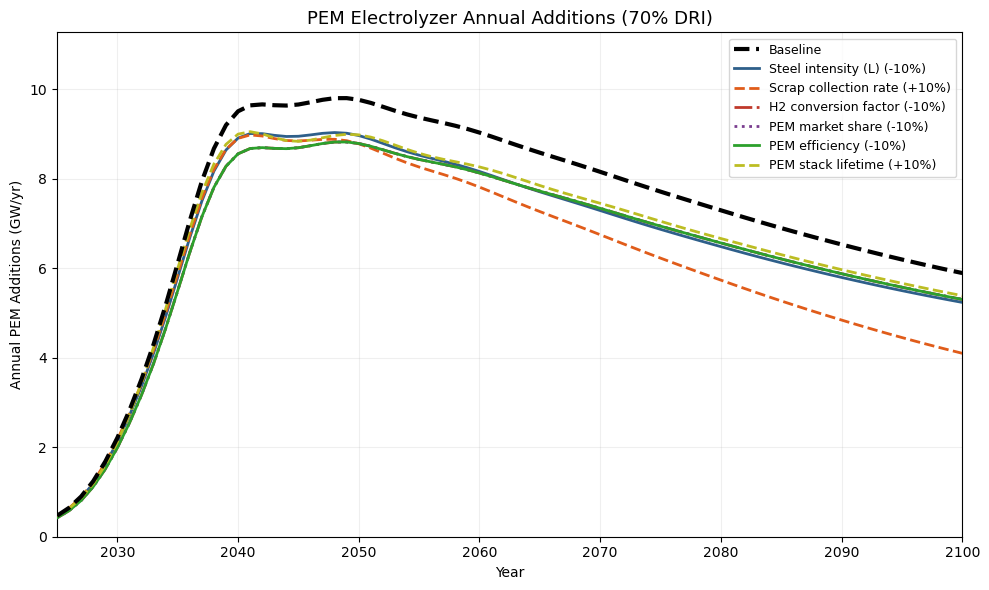

In [128]:
# Call like this:
cap_plot(pem_runs, 'i_PEM', 'Annual PEM Additions (GW/yr)',
         'PEM Electrolyzer Annual Additions (70% DRI)')

## Plot — AEC capacity (total + annual additions)

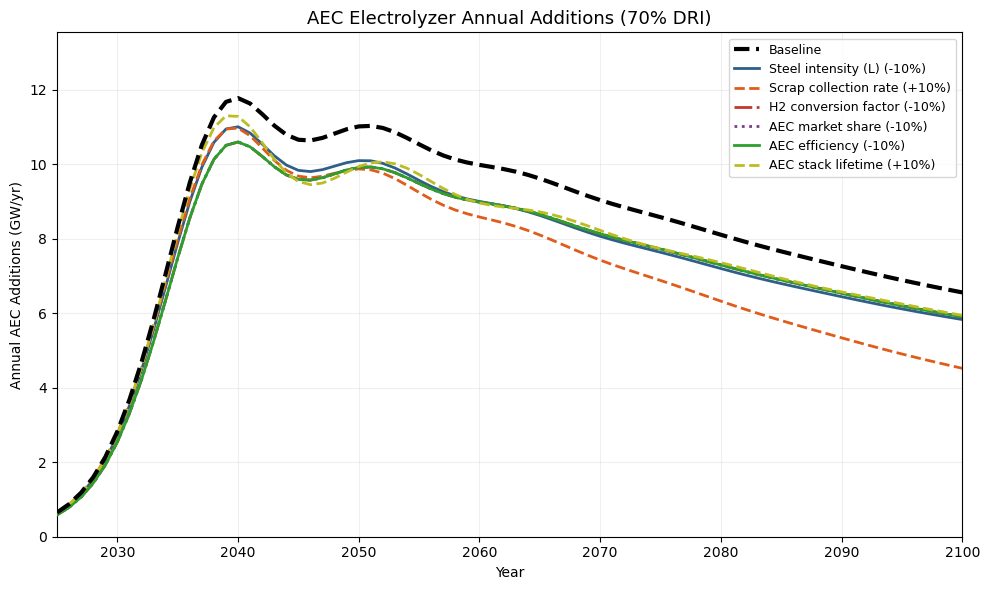

In [127]:
cap_plot(aec_runs, 'i_AEC', 'Annual AEC Additions (GW/yr)',
         'AEC Electrolyzer Annual Additions (70% DRI)')

## Heatmap — % deviation at 2050

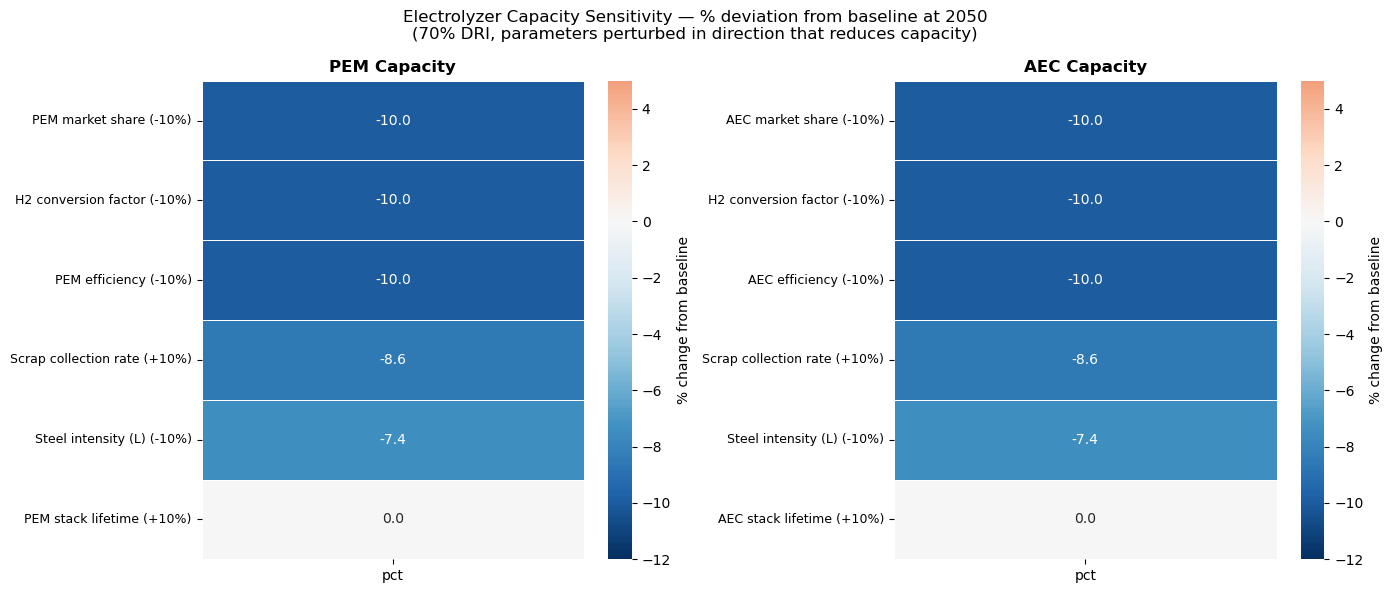

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Electrolyzer Capacity Sensitivity — % deviation from baseline at 2050\n(70% DRI, parameters perturbed in direction that reduces capacity)', fontsize=12)

for ax, runs, title, pct_key in zip(
    axes,
    [pem_runs, aec_runs],
    ['PEM Capacity', 'AEC Capacity'],
    ['pct_pem', 'pct_aec']
):
    data = pd.DataFrame([
        {'Parameter': f"{r['label']} ({r['direction']})", 'pct': r[pct_key]}
        for r in runs
    ]).set_index('Parameter')
    data = data.reindex(data['pct'].abs().sort_values(ascending=False).index)

    sns.heatmap(data[['pct']],
                annot=True, fmt='.1f',
                cmap='RdBu_r', center=0,
                vmin=-12, vmax=5,
                linewidths=0.5, ax=ax,
                cbar_kws={'label': '% change from baseline'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='y', labelsize=9)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Iridium intensity trajectory — standalone plot

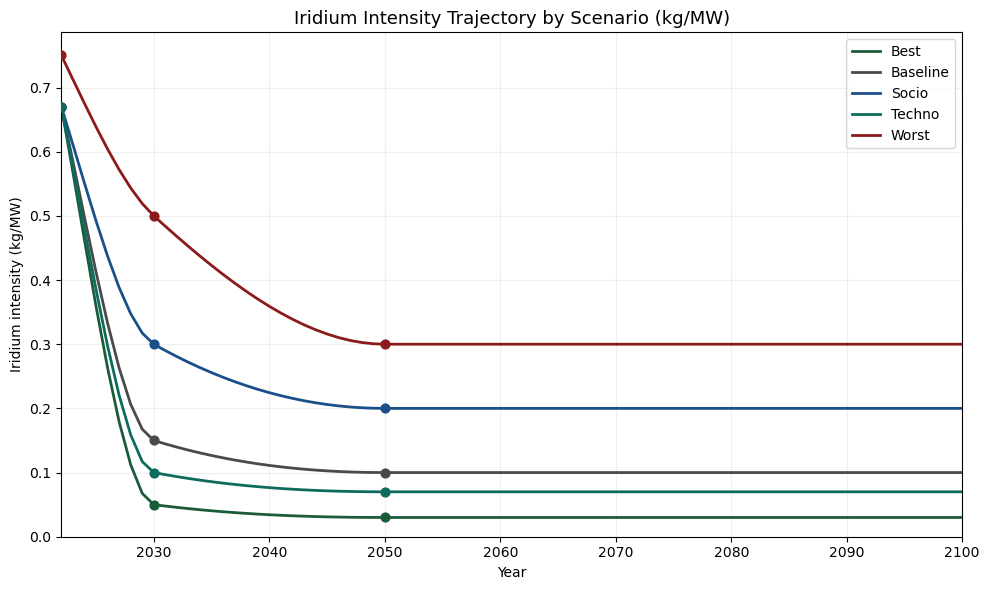

In [130]:
from scipy.interpolate import PchipInterpolator

scenarios_ir = {
    'Best':     (0.67, 0.05, 0.03),
    'Baseline': (0.67, 0.15, 0.10),
    'Socio':    (0.67, 0.30, 0.20),
    'Techno':   (0.67, 0.10, 0.07),
    'Worst':    (0.75, 0.50, 0.30),
}

sc_colors_ir = {
    'Best':     '#1a5c3a',
    'Baseline': '#4a4a4a',
    'Socio':    '#1B4F8A',
    'Techno':   '#0D6B5E',
    'Worst':    '#8B1A1A',
}

fig, ax = plt.subplots(figsize=(10, 6))

for name, (ir22, ir30, ir50) in scenarios_ir.items():
    interp = PchipInterpolator([2022, 2030, 2050, 2100], [ir22, ir30, ir50, ir50])
    ir_arr = np.clip(interp(years), 0, None)
    ax.plot(years, ir_arr, color=sc_colors_ir[name], linewidth=2, label=name)
    ax.scatter([2022, 2030, 2050], [ir22, ir30, ir50],
               color=sc_colors_ir[name], s=40, zorder=5)

ax.set_title('Iridium Intensity Trajectory by Scenario (kg/MW)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Iridium intensity (kg/MW)')
ax.set_xlim(2022, 2100)
ax.set_ylim(0)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Summary — what drives each electrolyzer fleet

In [119]:
print('PEM capacity drivers (% change at 2050):')
print('-' * 50)
for r in sorted(pem_runs, key=lambda x: abs(x['pct_pem']), reverse=True):
    print(f"  {r['label']:<30} ({r['direction']})  {r['pct_pem']:+.1f}%")

print('\nAEC capacity drivers (% change at 2050):')
print('-' * 50)
for r in sorted(aec_runs, key=lambda x: abs(x['pct_aec']), reverse=True):
    print(f"  {r['label']:<30} ({r['direction']})  {r['pct_aec']:+.1f}%")

PEM capacity drivers (% change at 2050):
--------------------------------------------------
  H2 conversion factor           (-10%)  -10.0%
  PEM market share               (-10%)  -10.0%
  PEM efficiency                 (-10%)  -10.0%
  PEM stack lifetime             (+10%)  +0.0%

AEC capacity drivers (% change at 2050):
--------------------------------------------------
  H2 conversion factor           (-10%)  -10.0%
  AEC market share               (-10%)  -10.0%
  AEC efficiency                 (-10%)  -10.0%
  AEC stack lifetime             (+10%)  +0.0%
